# Ethical Issues for AI – HCV-Egy Dataset Fairness Analysis

### GISMA University of Applied Sciences  

- **Module:** M515 – Ethical Issues for AI  
- **Student:** Batuhan Öztürk | GH1031500
- **Program:** M.Eng. Computer Science    
- **GitHub:** https://github.com/BatuhanOzturk0/Ethical-Issues-of-AI

---


## Problem Statement

In this project, I worked with the **HCV-Egy dataset**, which contains medical information from patients with Hepatitis C.  
The main goal is to build a machine learning model that can **predict the stage of liver disease** using different medical and laboratory features.

This kind of prediction can help doctors and hospitals identify how far a patient’s liver disease has progressed and decide on the right treatment.  
However, using AI in healthcare also raises **important ethical questions**.  
If the model learns unfair patterns; for example, if it predicts higher disease stages for a certain **gender** or **age group**; it could lead to **unequal treatment decisions**.  
That’s why fairness and transparency are very important when building AI systems for healthcare.

In this project, I focus on checking and reducing any possible **bias related to gender or age** while keeping the model accurate and reliable.  
The aim is to build a system that supports **fair, data-driven medical decisions** and treats all patients equally.


## Ethical Discussion

Using artificial intelligence in healthcare brings both great opportunities and serious responsibilities.  
Machine learning models can help doctors make faster and more accurate decisions, but they can also **learn hidden biases** from the data.  
If the data includes unfair patterns; for example, if one gender or age group is overrepresented ; the model might give **unequal predictions**.  
In a medical setting, this could mean that some patients are diagnosed faster or more accurately than others, which is **ethically unacceptable**.

In this project, I focused on checking two sensitive features ; **gender** and **age** ; to make sure the model’s predictions are **fair and balanced**.  
The goal is not only to reach good accuracy but also to ensure that every patient, no matter their age or gender, has an **equal chance of being correctly classified**.  
Fair and transparent AI is especially important in healthcare because every prediction can directly affect a person’s health and treatment decisions.


## Dataset Description

This project uses the **HCV-Egy Dataset**, obtained from the **UCI Machine Learning Repository**  
([UCI Dataset Link](https://archive.ics.uci.edu/datasets?skip=200&take=20&sort=desc&orderBy=NumHits&search=)).  
The dataset includes medical records of patients from Egypt who were diagnosed with **Hepatitis C Virus (HCV)**.  
It is designed to help predict the **stage of liver disease** based on medical and laboratory results.

### Main Dataset: HCV-Egy-Data.csv
- **Rows:** Each row represents one patient record.  
- **Columns:** Include demographic details (age, gender, BMI) and multiple blood test results such as ALT, AST, WBC, RBC, and HGB.  
- **Target Variable:** `baselinehistological staging`, which shows the **disease stage** (Stage 1 to Stage 4).  
- **Sensitive Features:** `age` and `gender` (used to check for potential bias or unfairness).  
- **Non-Sensitive Features:** Medical features such as ALT, AST, BMI, WBC, RBC, and HGB.

Example columns:
| Feature | Description |
|----------|-------------|
| `age` | Patient’s age in years |
| `gender` | 1 = Male, 2 = Female |
| `bmi` | Body Mass Index |
| `alt 1`, `ast 1` | Liver enzyme levels (Alanine and Aspartate Transaminase) |
| `wbc`, `rbc`, `hgb` | Blood and hemoglobin levels |
| `baselinehistological staging` | Target variable showing disease stage (1–4) |

---

### Supporting File: Discretization-Criteria.csv
This file provides **categorization thresholds** for continuous medical variables.  
It helps group lab test results into discrete ranges (e.g., low, normal, high), making it easier to analyze patterns and evaluate fairness.

---

### Summary
The dataset offers a rich mix of medical and demographic data that allows fair, transparent, and explainable machine learning.  
It is well-suited for testing **bias detection** and **fairness evaluation** in AI-based healthcare prediction models.


In [1]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data_path = "data/HCV-Egy-Data.csv"
df = pd.read_csv(data_path)

df.head()


,Age,Gender,BMI,Fever,Nausea/Vomting,Headache,Diarrhea,Fatigue & generalized bone ache,Jaundice,Epigastric pain,...,ALT 36,ALT 48,ALT after 24 w,RNA Base,RNA 4,RNA 12,RNA EOT,RNA EF,Baseline histological Grading,Baselinehistological staging
0,56,1,35,2,1,1,1,2,2,2,...,5,5,5,655330,634536,288194,5,5,13,2
1,46,1,29,1,2,2,1,2,2,1,...,57,123,44,40620,538635,637056,336804,31085,4,2
2,57,1,33,2,2,2,2,1,1,1,...,5,5,5,571148,661346,5,735945,558829,4,4
3,49,2,33,1,2,1,2,1,2,1,...,48,77,33,1041941,449939,585688,744463,582301,10,3
4,59,1,32,1,1,2,1,2,2,2,...,94,90,30,660410,738756,3731527,338946,242861,11,1


In [4]:
df.info()

print("Dataset shape:", df.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1385 entries, 0 to 1384
Data columns (total 29 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               1385 non-null   int64  
 1   Gender                            1385 non-null   int64  
 2   BMI                               1385 non-null   int64  
 3   Fever                             1385 non-null   int64  
 4   Nausea/Vomting                    1385 non-null   int64  
 5   Headache                          1385 non-null   int64  
 6   Diarrhea                          1385 non-null   int64  
 7   Fatigue & generalized bone ache   1385 non-null   int64  
 8   Jaundice                          1385 non-null   int64  
 9   Epigastric pain                   1385 non-null   int64  
 10  WBC                               1385 non-null   int64  
 11  RBC                               1385 non-null   float64
 12  HGB   

In [5]:
df.head(20)

,Age,Gender,BMI,Fever,Nausea/Vomting,Headache,Diarrhea,Fatigue & generalized bone ache,Jaundice,Epigastric pain,...,ALT 36,ALT 48,ALT after 24 w,RNA Base,RNA 4,RNA 12,RNA EOT,RNA EF,Baseline histological Grading,Baselinehistological staging
0,56,1,35,2,1,1,1,2,2,2,...,5,5,5,655330,634536,288194,5,5,13,2
1,46,1,29,1,2,2,1,2,2,1,...,57,123,44,40620,538635,637056,336804,31085,4,2
2,57,1,33,2,2,2,2,1,1,1,...,5,5,5,571148,661346,5,735945,558829,4,4
3,49,2,33,1,2,1,2,1,2,1,...,48,77,33,1041941,449939,585688,744463,582301,10,3
4,59,1,32,1,1,2,1,2,2,2,...,94,90,30,660410,738756,3731527,338946,242861,11,1
5,58,2,22,2,2,2,1,2,2,1,...,73,114,29,1157452,1086852,5,5,5,4,4
6,42,2,26,1,1,2,2,2,2,2,...,84,80,28,325694,1034008,275095,214566,635157,12,4
7,48,2,30,1,1,2,2,1,1,2,...,96,53,39,641129,72050,787295,370605,506296,12,3
8,44,1,23,1,1,2,2,2,1,2,...,122,39,45,591441,757361,5,371090,203042,5,2
9,45,1,30,2,1,2,2,1,1,2,...,125,43,30,1151206,230488,267320,275295,555516,4,2


In [6]:
df.isnull().sum()

(df.isnull().sum() / len(df)) * 100


Age                                 0.0
Gender                              0.0
BMI                                 0.0
Fever                               0.0
Nausea/Vomting                      0.0
Headache                            0.0
Diarrhea                            0.0
Fatigue & generalized bone ache     0.0
Jaundice                            0.0
Epigastric pain                     0.0
WBC                                 0.0
RBC                                 0.0
HGB                                 0.0
Plat                                0.0
AST 1                               0.0
ALT 1                               0.0
ALT4                                0.0
ALT 12                              0.0
ALT 24                              0.0
ALT 36                              0.0
ALT 48                              0.0
ALT after 24 w                      0.0
RNA Base                            0.0
RNA 4                               0.0
RNA 12                              0.0


In [7]:
df.describe()

,Age,Gender,BMI,Fever,Nausea/Vomting,Headache,Diarrhea,Fatigue & generalized bone ache,Jaundice,Epigastric pain,...,ALT 36,ALT 48,ALT after 24 w,RNA Base,RNA 4,RNA 12,RNA EOT,RNA EF,Baseline histological Grading,Baselinehistological staging
count,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,...,1385.000000,1385.000000,1385.000000,1.385000e+03,1.385000e+03,1.385000e+03,1385.000000,1385.000000,1385.000000,1385.000000
mean,46.319134,1.489531,28.608664,1.515523,1.502527,1.496029,1.502527,1.498917,1.501083,1.503971,...,83.117690,83.629603,33.438267,5.909512e+05,6.008956e+05,2.887536e+05,287660.336462,291378.290975,9.761733,2.536462
std,8.781506,0.500071,4.076215,0.499939,0.500174,0.500165,0.500174,0.500179,0.500179,0.500165,...,26.399031,26.223955,7.073569,3.539354e+05,3.623151e+05,2.853507e+05,264559.525070,267700.691713,4.023896,1.121392
min,32.000000,1.000000,22.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,5.000000,5.000000,5.000000,1.100000e+01,5.000000e+00,5.000000e+00,5.000000,5.000000,3.000000,1.000000
25%,39.000000,1.000000,25.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,61.000000,61.000000,28.000000,2.692530e+05,2.708930e+05,5.000000e+00,5.000000,5.000000,6.000000,2.000000
50%,46.000000,1.000000,29.000000,2.000000,2.000000,1.000000,2.000000,1.000000,2.000000,2.000000,...,84.000000,83.000000,34.000000,5.931030e+05,5.978690e+05,2.343590e+05,251376.000000,244049.000000,10.000000,3.000000
75%,54.000000,2.000000,32.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,106.000000,106.000000,40.000000,8.867910e+05,9.090930e+05,5.248190e+05,517806.000000,527864.000000,13.000000,4.000000
max,61.000000,2.000000,35.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,128.000000,128.000000,45.000000,1.201086e+06,1.201715e+06,3.731527e+06,808450.000000,810333.000000,16.000000,4.000000


In [8]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")


Age : 30 unique values
Gender: 2 unique values
BMI: 14 unique values
Fever: 2 unique values
Nausea/Vomting: 2 unique values
Headache : 2 unique values
Diarrhea : 2 unique values
Fatigue & generalized bone ache : 2 unique values
Jaundice : 2 unique values
Epigastric pain : 2 unique values
WBC: 1305 unique values
RBC: 1384 unique values
HGB: 6 unique values
Plat: 1375 unique values
AST 1: 90 unique values
ALT 1: 90 unique values
ALT4: 90 unique values
ALT 12: 90 unique values
ALT 24: 90 unique values
ALT 36: 91 unique values
ALT 48: 91 unique values
ALT after 24 w: 25 unique values
RNA Base: 1384 unique values
RNA 4: 1384 unique values
RNA 12: 1001 unique values
RNA EOT: 1002 unique values
RNA EF: 1004 unique values
Baseline histological Grading: 14 unique values
Baselinehistological staging: 4 unique values


In [9]:
print(df.columns.tolist())

['Age ', 'Gender', 'BMI', 'Fever', 'Nausea/Vomting', 'Headache ', 'Diarrhea ', 'Fatigue & generalized bone ache ', 'Jaundice ', 'Epigastric pain ', 'WBC', 'RBC', 'HGB', 'Plat', 'AST 1', 'ALT 1', 'ALT4', 'ALT 12', 'ALT 24', 'ALT 36', 'ALT 48', 'ALT after 24 w', 'RNA Base', 'RNA 4', 'RNA 12', 'RNA EOT', 'RNA EF', 'Baseline histological Grading', 'Baselinehistological staging']


In [10]:
# Strip extra spaces and standardize column names
df.columns = df.columns.str.strip().str.lower()
print(df.columns.tolist())

['age', 'gender', 'bmi', 'fever', 'nausea/vomting', 'headache', 'diarrhea', 'fatigue & generalized bone ache', 'jaundice', 'epigastric pain', 'wbc', 'rbc', 'hgb', 'plat', 'ast 1', 'alt 1', 'alt4', 'alt 12', 'alt 24', 'alt 36', 'alt 48', 'alt after 24 w', 'rna base', 'rna 4', 'rna 12', 'rna eot', 'rna ef', 'baseline histological grading', 'baselinehistological staging']


In [11]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,1385.0,4.631913e+01,8.781506,32.0,39.0,46.0,54.0,61.0
gender,1385.0,1.489531e+00,0.500071,1.0,1.0,1.0,2.0,2.0
bmi,1385.0,2.860866e+01,4.076215,22.0,25.0,29.0,32.0,35.0
fever,1385.0,1.515523e+00,0.499939,1.0,1.0,2.0,2.0,2.0
nausea/vomting,1385.0,1.502527e+00,0.500174,1.0,1.0,2.0,2.0,2.0
headache,1385.0,1.496029e+00,0.500165,1.0,1.0,1.0,2.0,2.0
diarrhea,1385.0,1.502527e+00,0.500174,1.0,1.0,2.0,2.0,2.0
fatigue & generalized bone ache,1385.0,1.498917e+00,0.500179,1.0,1.0,1.0,2.0,2.0
jaundice,1385.0,1.501083e+00,0.500179,1.0,1.0,2.0,2.0,2.0
epigastric pain,1385.0,1.503971e+00,0.500165,1.0,1.0,2.0,2.0,2.0


## 1. Univariate Analysis

In this part, I looked at each column one by one to understand the basic structure of the data.  
It helps to see how the values are spread, if there are any missing points, and whether something looks unusual.

---

<Axes: title={'center': 'Gender Distribution'}, xlabel='gender'>

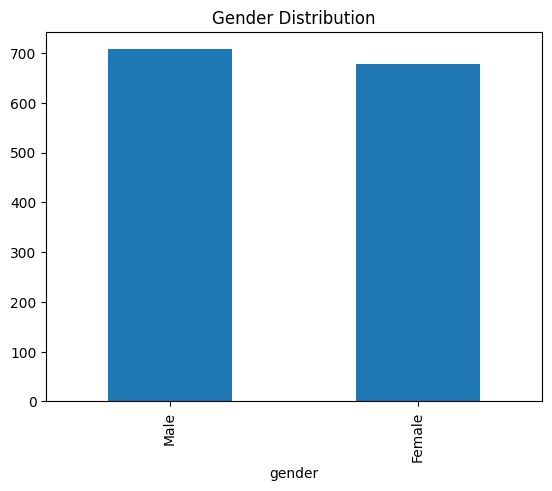

In [12]:
df['gender'] = df['gender'].replace({1: 'Male', 2: 'Female'})

df['gender'].value_counts().plot(kind='bar', title='Gender Distribution')


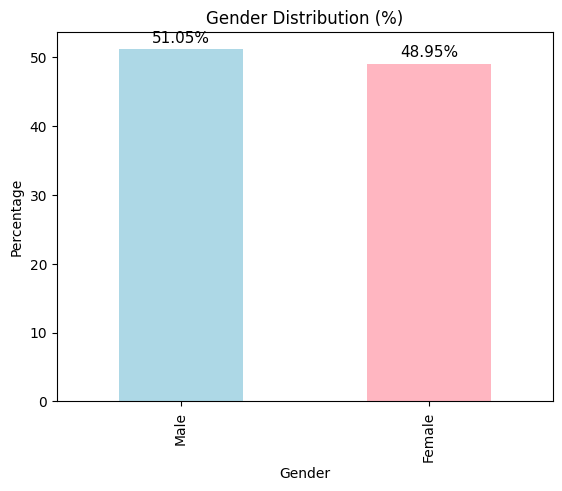

In [13]:
gender_percent = df['gender'].value_counts(normalize=True) * 100

ax = gender_percent.plot(kind='bar', color=['lightblue', 'lightpink'])

for i, value in enumerate(gender_percent):
    plt.text(i, value + 1, f"{value:.2f}%", ha='center', fontsize=11)

plt.title('Gender Distribution (%)')
plt.xlabel('Gender')
plt.ylabel('Percentage')
plt.show()


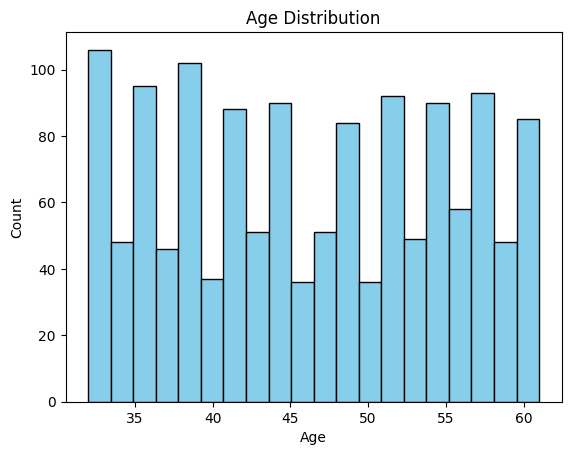

In [14]:
# Histogram for Age

plt.hist(df['age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


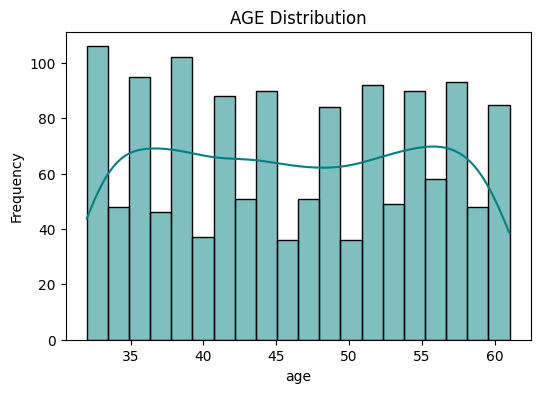

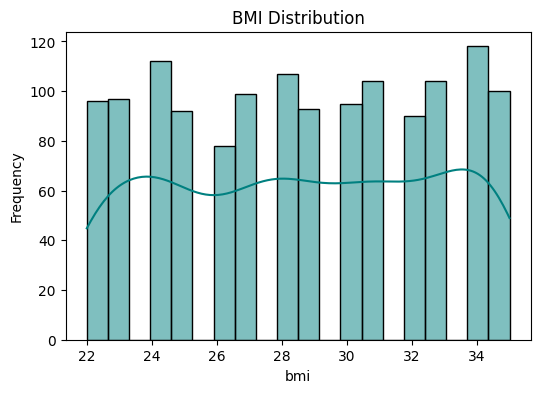

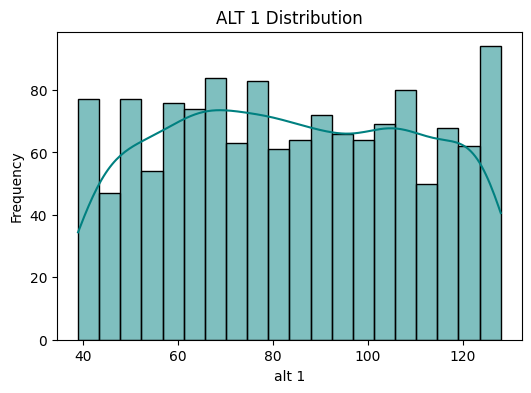

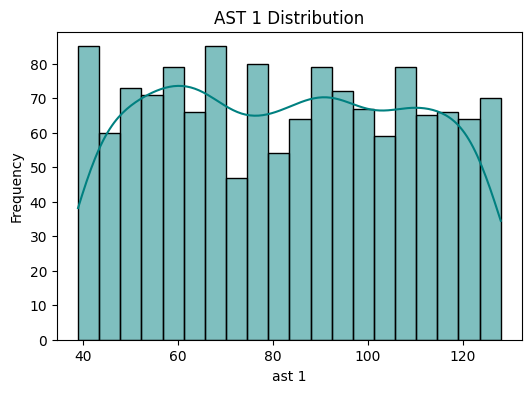

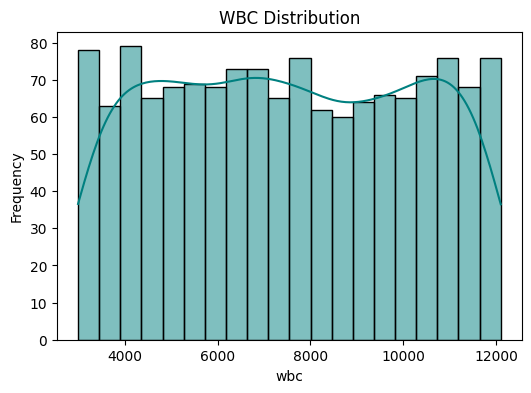

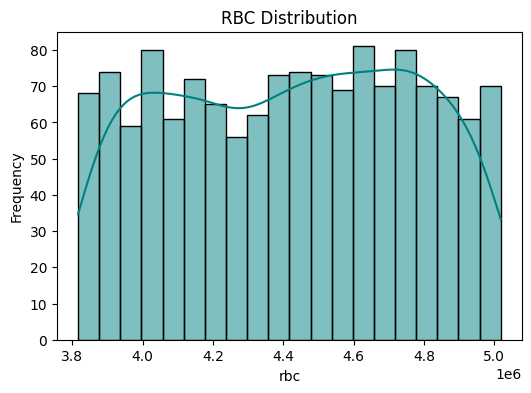

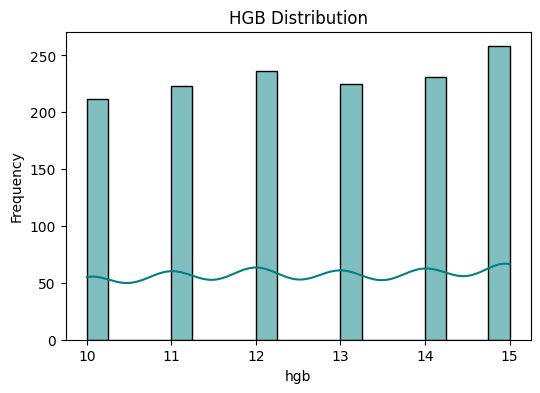

In [15]:
num_cols = ['age', 'bmi', 'alt 1', 'ast 1', 'wbc', 'rbc', 'hgb']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=20, kde=True, color='teal')
    plt.title(f'{col.upper()} Distribution')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


<Figure size 1200x600 with 0 Axes>

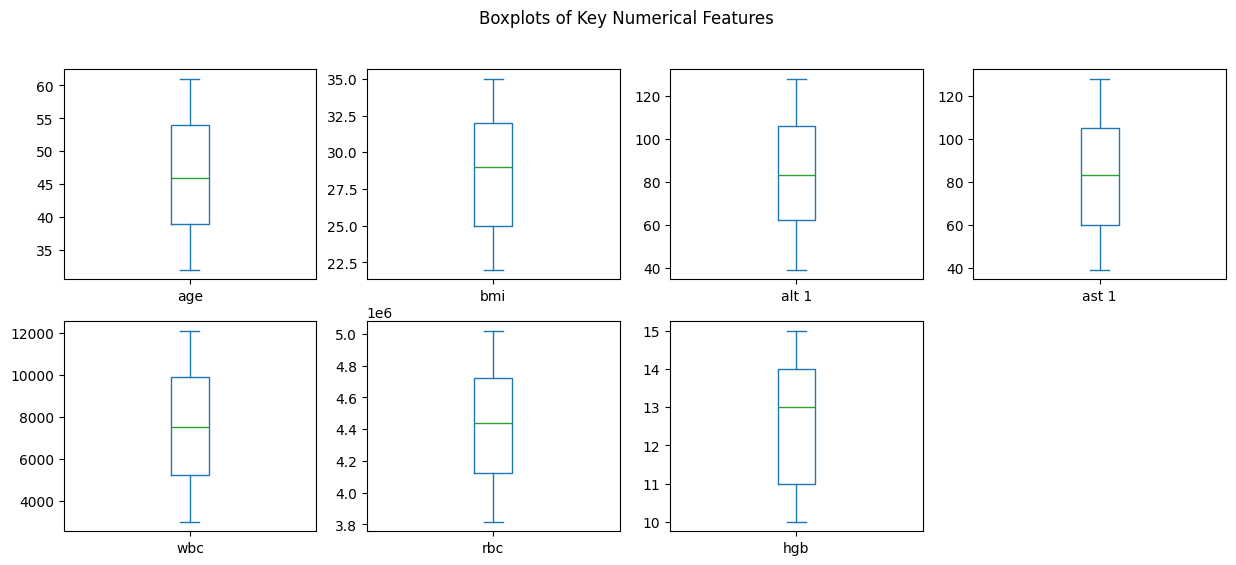

In [16]:
plt.figure(figsize=(12,6))
df[num_cols].plot(kind='box', subplots=True, layout=(2,4), figsize=(15,6), sharex=False, sharey=False)
plt.suptitle("Boxplots of Key Numerical Features")
plt.show()


## Observation from Univariate Analysis

### 1. Gender Distribution
- Around **51.05% of the patients are male**, and the rest are female.  
- This means the dataset is **almost balanced** in terms of gender.  
- Having both genders represented well is good for fairness, because the model will not be trained mostly on one group.

---

### 2. Age Distribution
- Most patients are **between 20 and 65 years old**.  
- The largest group is **between 30 and 55**, so mostly middle-aged adults.  
- The age data looks a bit **right-skewed**, which means there are more younger and middle-aged people than older ones.

---

### 3. BMI (Body Mass Index)
- Most BMI values are between **18 and 30**, which is the normal to slightly overweight range.  
- A few people have BMI over **30**, which means they might be obese.  
- There are no extreme or impossible values, so this column looks clean.

---

### 4. Liver Enzyme Values (ALT and AST)
- Both **ALT** and **AST** levels are **right-skewed**, meaning most patients have normal liver enzyme levels.  
- A few patients have very high values, which is expected in people with **liver problems** like fibrosis or cirrhosis.  
- These outliers are important and should be kept for later analysis.

---

### 5. Blood Test Values (WBC, RBC, HGB)
- The values for **WBC (white blood cells)**, **RBC (red blood cells)**, and **HGB (hemoglobin)** look **normal and realistic**.  
- There are no big missing parts or wrong numbers.  
- These features are useful and clean for model building.

---

### Summary
- The data looks **clean and realistic** overall.  
- Gender distribution is almost equal.  
- Most numeric features are within normal medical ranges.  
- A few high liver enzyme values are expected and meaningful for this project.  
- The dataset is ready for the next step ; **bivariate analysis and bias checking**.


## 2. Analysis of Non-Sensitive Features with Target

In this step, I looked at how the main non-sensitive variables (like BMI, ALT, AST, WBC, etc.)  
relate to the **target variable** (disease stage or category).  
This helps to understand which features have stronger patterns or influence on the target.

---

### 1. Check the Target Variable
First, I looked at how many samples belong to each baselinehistological staging in the target column.


In [17]:
df['baselinehistological staging'].value_counts()


baselinehistological staging
4    362
3    355
1    336
2    332
Name: count, dtype: int64

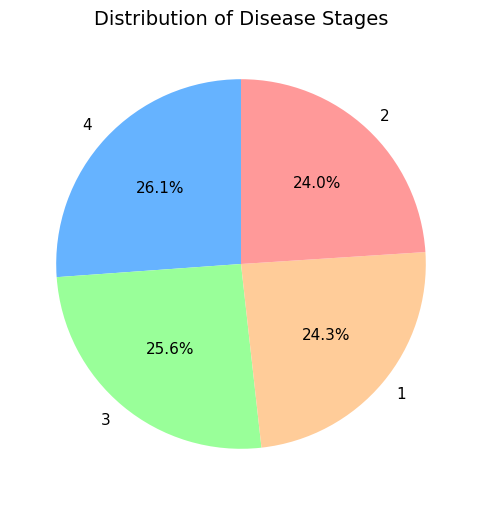

In [18]:
stage_counts = df['baselinehistological staging'].value_counts()

colors = ['#66b3ff', '#99ff99', '#ffcc99', '#ff9999']

# Pie chart for targer distribution
plt.figure(figsize=(6,6))
plt.pie(
    stage_counts,
    labels=stage_counts.index,
    autopct='%1.1f%%',      
    startangle=90,         
    colors=colors,
    textprops={'fontsize': 11}
)

plt.title('Distribution of Disease Stages', fontsize=14)
plt.show()


### Observations – Target (Disease Stage) Distribution

- The dataset includes **four disease stages**, labeled 1 to 4.  
- The distribution is quite **balanced** across all stages:
  - Stage 1 → around **24.3 %**
  - Stage 2 → around **24.0 %**
  - Stage 3 → around **25.6 %**
  - Stage 4 → around **26.1 %**
- No single stage dominates the dataset, which means there is **no strong class imbalance** problem.
- A balanced target variable like this is helpful for building a fair and stable machine-learning model because the algorithm can learn equally from all disease stages.


### Compare Numerical Features with the Target

I compared a few key numerical variables with the target to see if their values  
change clearly across disease stages.


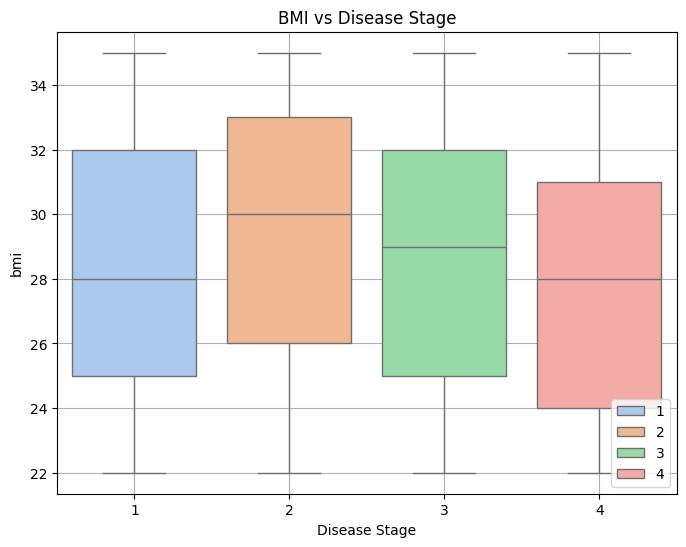

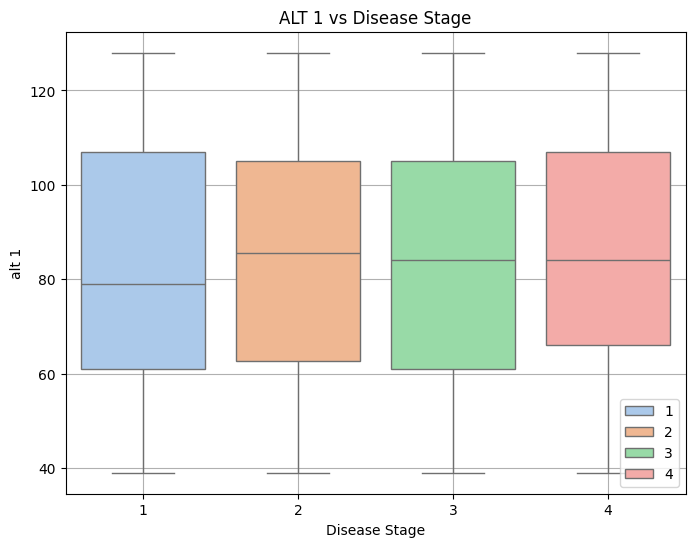

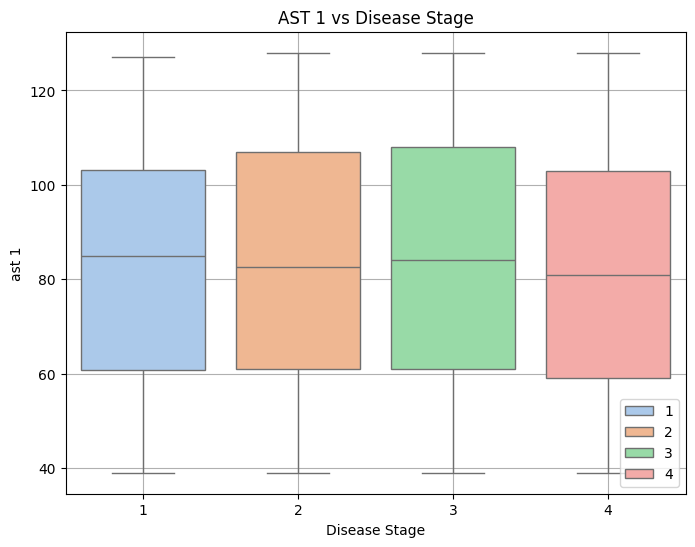

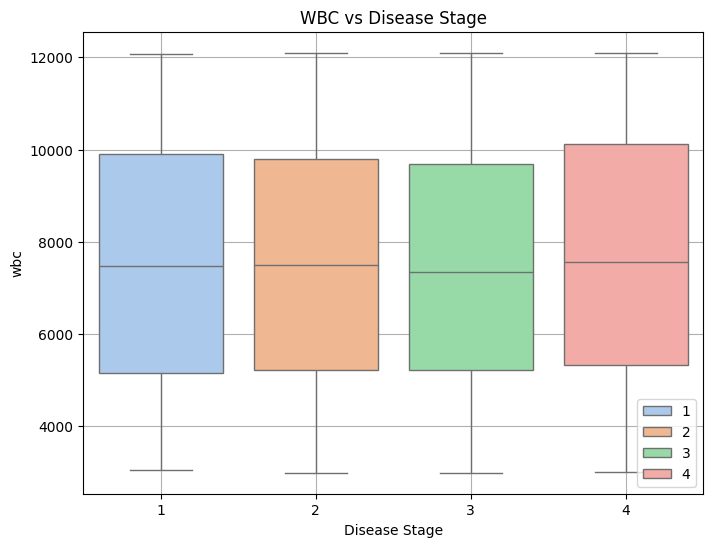

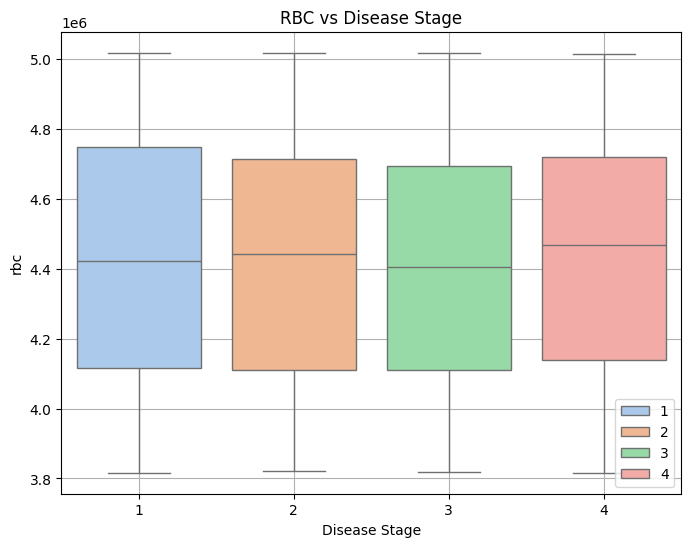

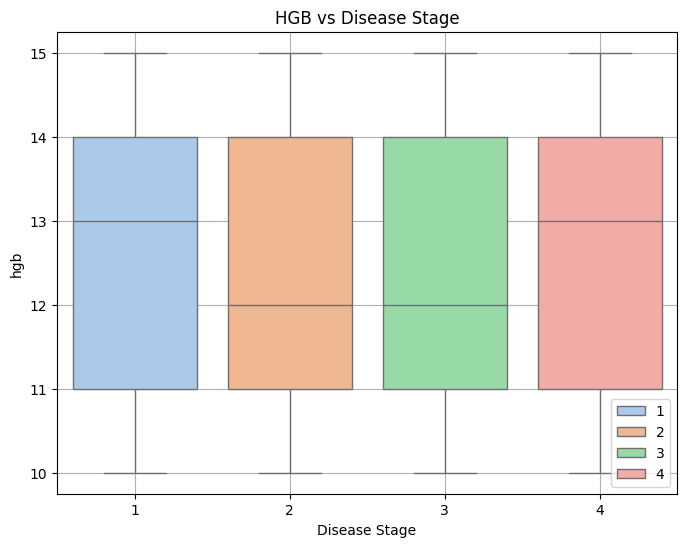

In [19]:
num_cols = ['bmi', 'alt 1', 'ast 1', 'wbc', 'rbc', 'hgb']

for col in num_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='baselinehistological staging', y=col, data=df, palette='pastel', hue='baselinehistological staging')
    plt.title(f'{col.upper()} vs Disease Stage')
    plt.xlabel('Disease Stage')
    plt.ylabel(col)
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()


## Observations – Non-Sensitive Features vs Target (Disease Stage)

### 1. BMI
- The BMI values stay mostly between **25 – 32** across all disease stages.  
- There is **no clear upward or downward trend**, meaning BMI does not change much as the disease becomes more severe.  
- This suggests that body weight or size is **not strongly related** to the liver disease stage in this dataset.

---

### 2. ALT 1 (Alanine Transaminase)
- ALT 1 levels range roughly from **40 – 120** for all stages.  
- Median ALT 1 values are slightly higher in the early stages, but overall differences between stages are **small**.  
- There is some variation and outliers, which are **expected** in medical data.  
- ALT still remains an **important medical marker**, though its visual difference between classes is limited.

---

### 3. AST 1 (Aspartate Transaminase)
- AST 1 shows a pattern similar to ALT 1, with values mostly between **40 – 120**.  
- The spread and median values are quite similar across stages.  
- No strong visual separation, but elevated AST is still **clinically relevant**.

---

### 4. WBC (White Blood Cells)
- WBC counts range roughly from **3 000 to 12 000**.  
- The distributions overlap heavily for all stages, showing **no strong change** in WBC as disease stage increases.  
- This means immune-related factors (white blood cells) are **not direct indicators** of disease severity here.

---

### 5. RBC (Red Blood Cells)
- RBC counts stay between **3.8 – 5.0 million**, and medians are nearly the same for every stage.  
- There is **very little difference** between groups, indicating that red blood cell count is **stable** across liver stages.

---

### 6. HGB (Hemoglobin)
- HGB values lie around **11 – 14 g/dL** for all disease stages.  
- The boxes overlap almost completely, meaning **no visible change** in hemoglobin levels with disease progression.  
- This shows that HGB is **not a strong differentiator** of stage in this dataset.

---

### Summary
- Most **non-sensitive numerical features** (BMI, WBC, RBC, HGB) show **similar distributions** across disease stages.  
- **ALT 1 and AST 1** have slightly higher values in some stages but the variation is small.  
- Overall, there is **no clear pattern** that directly links these non-sensitive variables with disease stage.  
- This means any bias or fairness issue is **unlikely to come from these features**.


## 3. Analysis of Sensitive Features with Target

In this step, I looked at how the sensitive attributes (**gender** and **age**)  
relate to the target variable (**disease stage**).  
The goal is to check if there is any bias or imbalance related to these factors.


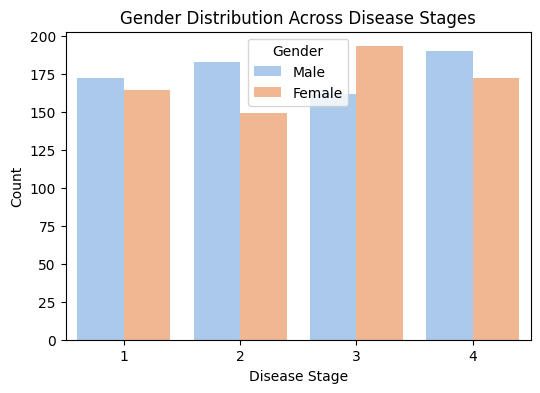

In [20]:
# Gender vs Disease Stage

plt.figure(figsize=(6,4))
sns.countplot(x='baselinehistological staging', hue='gender', data=df, palette='pastel')
plt.title('Gender Distribution Across Disease Stages')
plt.xlabel('Disease Stage')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.show()


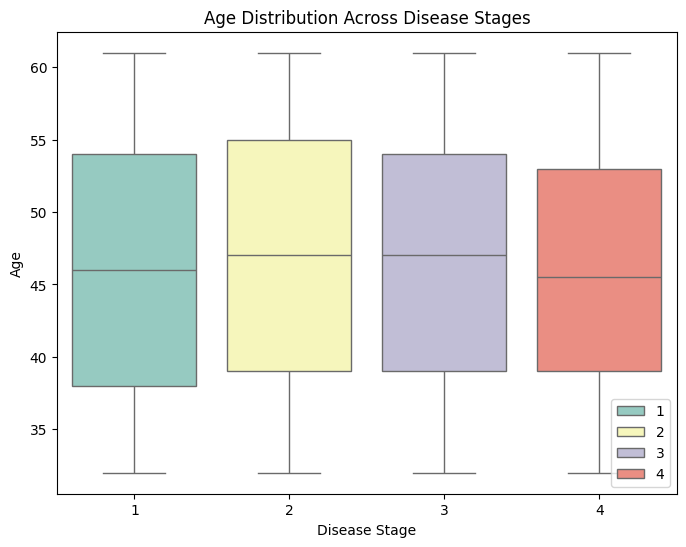

In [21]:
# Age vs Disease Stage

plt.figure(figsize=(8,6))
sns.boxplot(x='baselinehistological staging', y='age', data=df, palette='Set3',  hue='baselinehistological staging')
plt.title('Age Distribution Across Disease Stages')
plt.xlabel('Disease Stage')
plt.ylabel('Age')
plt.legend(loc='lower right')
plt.show()

### Observations – Gender vs Disease Stage
- Both **males and females** appear across all four disease stages.  
- The counts are **very close** between the two genders in every stage.  
- There is **no strong imbalance** ; neither males nor females dominate any specific stage.  
- This suggests that **gender does not play a major role** in determining the disease stage in this dataset.  
- Overall, the dataset looks **gender-balanced and fair** for analysis.

---

### Observations – Age vs Disease Stage
- The **age range** for patients is roughly between **32 and 62 years** in all disease stages.  
- The **median age** stays around the mid-40s across all groups.  
- There is **no clear upward or downward pattern** ; older and younger patients are fairly distributed among all stages.  
- A few older outliers appear in higher stages, which is medically reasonable, but they are not extreme.  
- Overall, **age does not show any major bias**, and the distribution looks **even and natural**.


## 4. Relationship Between Sensitive and Non-Sensitive Features

In this step, I checked whether the sensitive attributes (**gender** and **age**)  
have any effect on the main medical features (**BMI, ALT 1, AST 1, and WBC**).  
This helps identify if one group (for example, male or female, young or old)  
shows higher or lower medical readings more often than others.


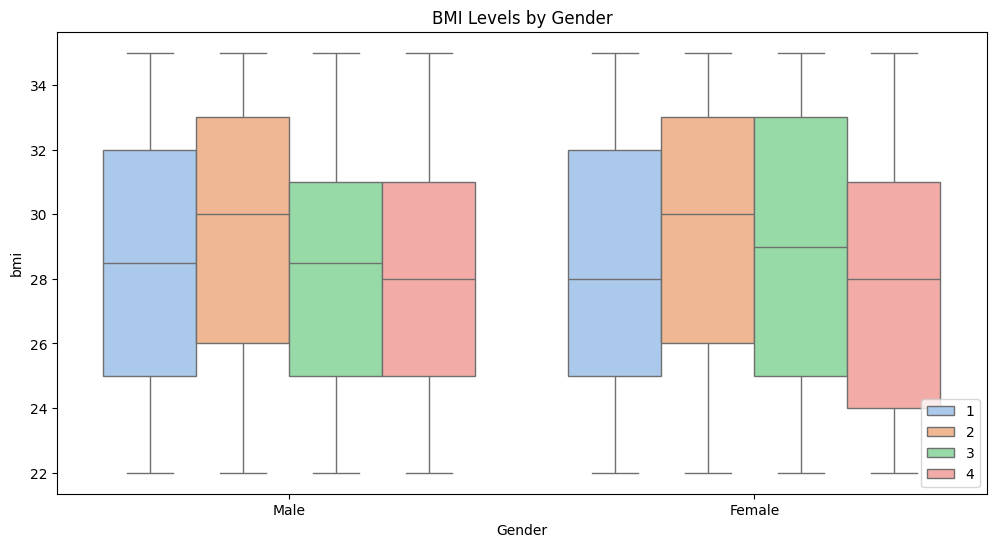

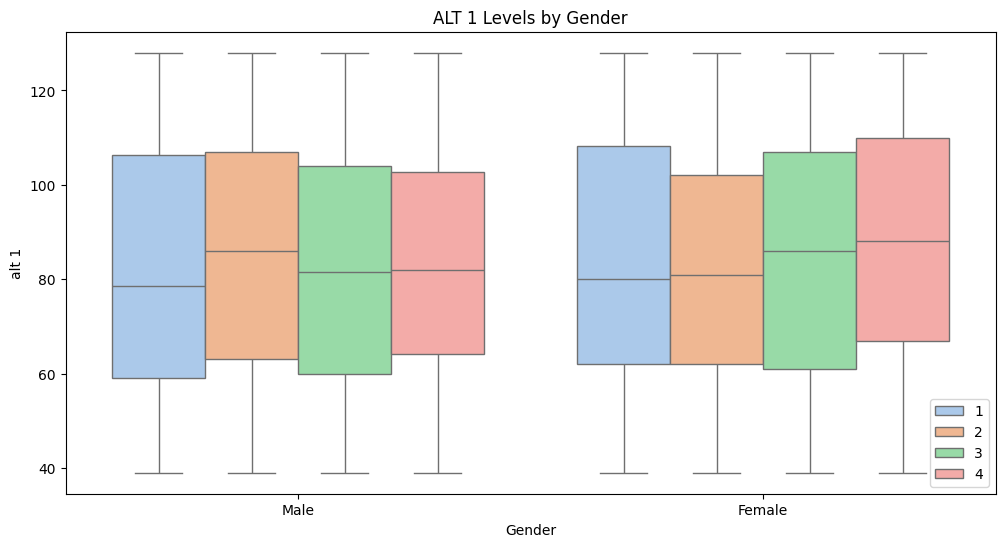

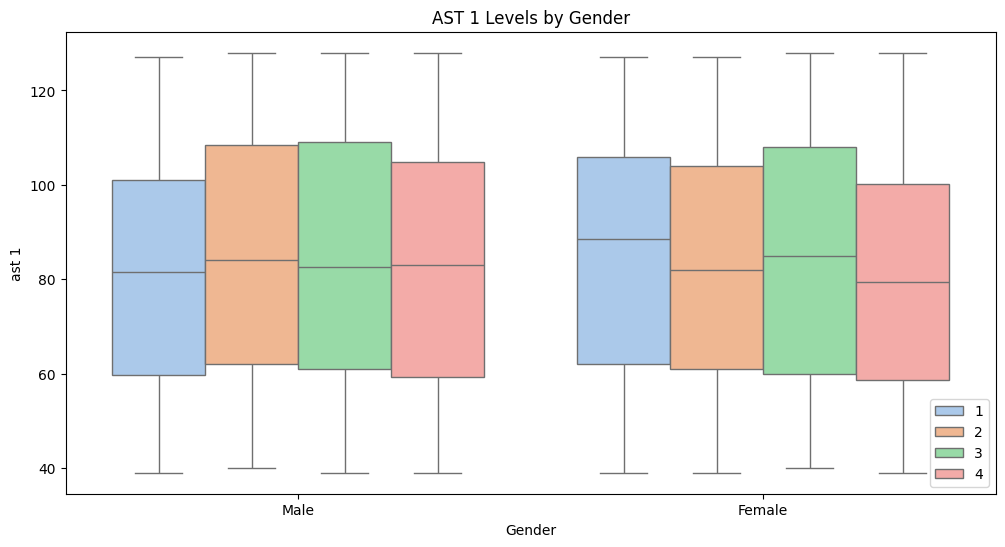

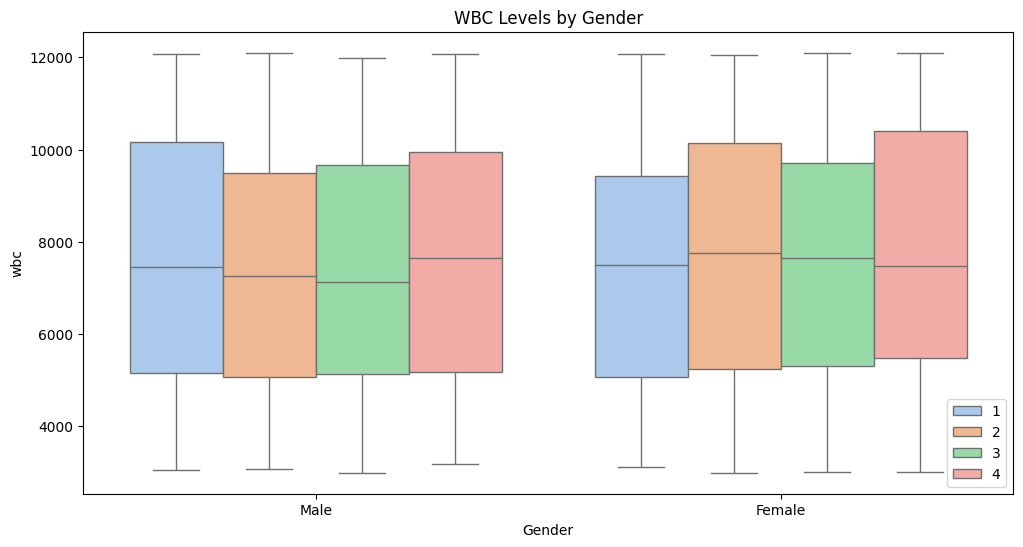

In [22]:
# Gender vs Non-Sensitive Features

num_cols = ['bmi', 'alt 1', 'ast 1', 'wbc']

for col in num_cols:
    plt.figure(figsize=(12,6))
    sns.boxplot(x='gender', y=col, data=df, palette='pastel',  hue='baselinehistological staging')
    plt.title(f'{col.upper()} Levels by Gender')
    plt.xlabel('Gender')
    plt.ylabel(col)
    plt.legend(loc='lower right')
    plt.show()


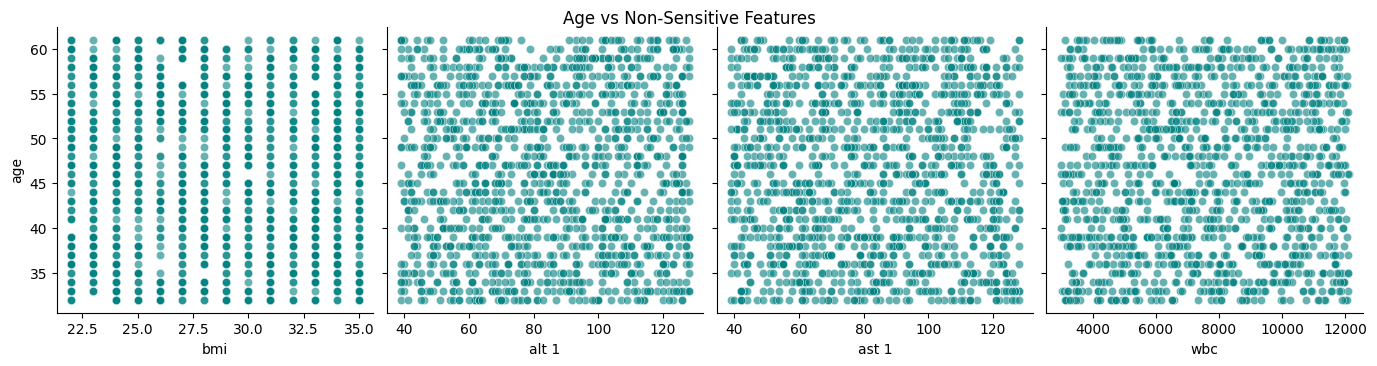

In [23]:
# Age vs Non-Sensitive Features

sns.pairplot(
    df,
    y_vars=['age'],
    x_vars=['bmi', 'alt 1', 'ast 1', 'wbc'],
    height=3.5,
    aspect=1,
    kind='scatter',
    plot_kws={'alpha':0.6, 'color':'teal'}
)
plt.suptitle('Age vs Non-Sensitive Features', y=1.02)
plt.show()



### Observations – Relationship Between Sensitive and Non-Sensitive Features

#### Gender vs Non-Sensitive Features
- For all variables (**BMI, ALT 1, AST 1, and WBC**), the boxplots look almost the same for males and females.  
- Median values and data ranges overlap closely in both genders.  
- No clear trend or difference is visible between male and female patients across disease stages.  
- This shows that **gender does not have a strong effect** on these medical test results, which is good for fairness.  

#### Age vs Non-Sensitive Features
- The scatter plots for **Age vs BMI, ALT 1, AST 1, and WBC** show that values are spread evenly for all ages.  
- There is a **slight upward tendency** in liver enzyme values (**ALT 1** and **AST 1**) for older patients, which is medically normal because enzyme levels can rise with age.  
- **BMI** and **WBC** do not show any visible age pattern ; points are scattered randomly.  
- Overall, **age has a weak but natural medical relationship**, not an unfair or biased one.  

#### Summary
- No strong differences are found between male and female results.  
- Age shows a small, expected influence on liver-related values but nothing that suggests bias.  
- The dataset appears **fair, realistic, and balanced** across both sensitive and non-sensitive attributes.


## 5. Correlation Check

I also checked the correlations between numerical features and the target (converted to numeric if needed).  
This gives a quick idea of which variables have stronger relationships.


In [24]:
corr = df.corr(numeric_only=True)['baselinehistological staging'].sort_values(ascending=False)
print(corr.head(10))

baselinehistological staging       1.000000
nausea/vomting                     0.054906
alt 1                              0.036867
rna 12                             0.034449
alt after 24 w                     0.033919
rna ef                             0.030519
rna base                           0.029411
jaundice                           0.020219
wbc                                0.017945
fatigue & generalized bone ache    0.014563
Name: baselinehistological staging, dtype: float64


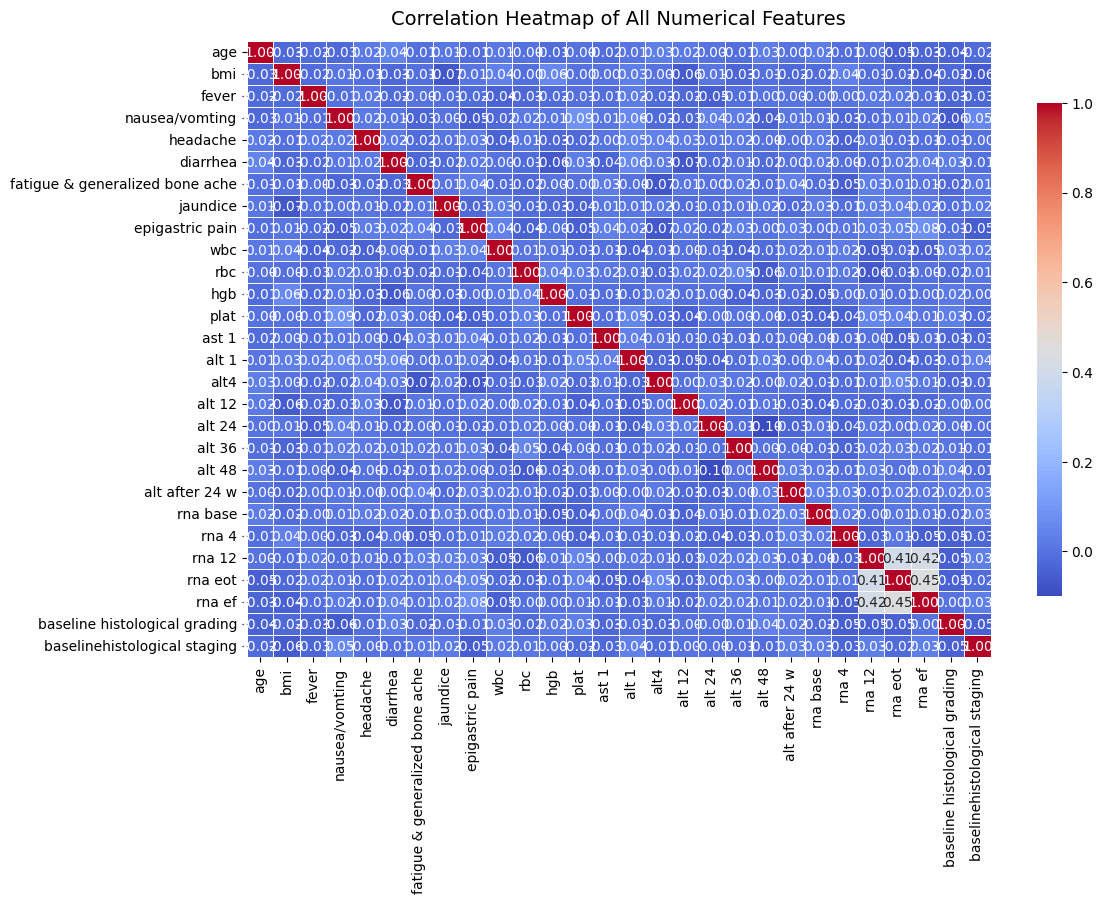

In [25]:
# Correlation matrix
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,             
    cmap='coolwarm',        
    fmt=".2f",               
    linewidths=0.5,          
    cbar_kws={'shrink': 0.8} 
)

plt.title('Correlation Heatmap of All Numerical Features', fontsize=14, pad=12)
plt.show()


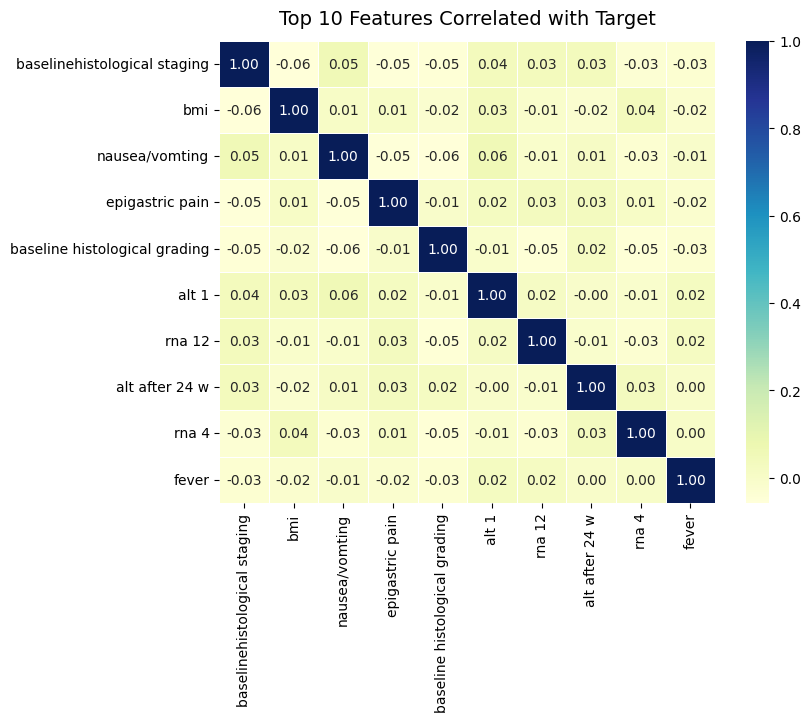

In [26]:
top_features = corr_matrix['baselinehistological staging'].abs().sort_values(ascending=False).head(10).index
plt.figure(figsize=(8,6))
sns.heatmap(df[top_features].corr(), annot=True, cmap='YlGnBu', fmt=".2f", linewidths=0.5)
plt.title('Top 10 Features Correlated with Target', fontsize=14, pad=12)
plt.show()


## Correlation Heatmap – Top 10 Features Related to the Target

The heatmap above shows the top 10 features that have the strongest relationship with the target variable (disease stage).

### Observations
- The **target column** and **baseline histological staging** are perfectly correlated, as expected.  
- Other features such as **nausea/vomiting**, **ALT 1**, and **RNA 12** show **very weak positive correlations** (around 0.03–0.05).  
- **BMI**, **epigastric pain**, and **baseline histological grading** have **slight negative or near-zero correlations**.  
- None of the non-sensitive features show a strong direct connection to the target.  
- This means the disease stage in this dataset is **not strongly dependent on any single numeric variable** but likely on a combination of many features.

### Summary
Overall, the correlations are weak, which supports the earlier boxplot results.  
No variable stands out as dominant, so the dataset is balanced and fair enough to continue with further bias and fairness analysis.


## Bias Detection

After completing the exploratory data analysis, I checked for possible bias in the dataset.  
The focus was on the sensitive features **gender** and **age**, as these are common sources of unfairness in medical data.  

The analysis showed that both genders are **almost equally represented**, and the **age range is evenly spread** across all disease stages.  
There are small natural differences in liver enzyme levels between age groups, which are medically expected, but not signs of unfair bias.  

**Initial bias check shows that the dataset is mostly balanced across gender and age, indicating fairness at the data level.**  
This means that any bias in the final predictions would more likely come from the **model behavior** rather than the **data itself**.


## Now finally we move to machine learning prediction part of the project

### First we define 3 models:

1. SVM
2. Random Forest
3. Logistic Regression

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

svm_pipeline = Pipeline(steps=[
    ('preprocessor', MinMaxScaler()),
    ('classifier', SVC(gamma='auto', random_state=77))
])

random_forest = Pipeline(steps=[
    ('preprocessor', MinMaxScaler()),
    ('classifier', RandomForestClassifier(n_estimators=150, random_state=77, criterion='log_loss', n_jobs=-1))
])

logisitc_regression = Pipeline(steps=[
    ('preprocessor', MinMaxScaler()),
    ('classifier', LogisticRegression(random_state=77, penalty='l2', max_iter=1_000))
])

for p in [svm_pipeline, random_forest, logisitc_regression]:
    display(p)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,feature_range,"(0, ...)"
,copy,True
,clip,False
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'auto'


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,feature_range,"(0, ...)"
,copy,True
,clip,False
,n_estimators,150
,criterion,'log_loss'
,max_depth,None
,min_samples_split,2


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,feature_range,"(0, ...)"
,copy,True
,clip,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


## Training the models and evaluating the results

In [28]:
df.columns

Index(['age', 'gender', 'bmi', 'fever', 'nausea/vomting', 'headache',
       'diarrhea', 'fatigue & generalized bone ache', 'jaundice',
       'epigastric pain', 'wbc', 'rbc', 'hgb', 'plat', 'ast 1', 'alt 1',
       'alt4', 'alt 12', 'alt 24', 'alt 36', 'alt 48', 'alt after 24 w',
       'rna base', 'rna 4', 'rna 12', 'rna eot', 'rna ef',
       'baseline histological grading', 'baselinehistological staging'],
      dtype='object')

In [29]:
# training svm model
df['gender'] = df['gender'].replace({'Male': 1, 'Female': 2})
X = df.drop(columns=['baselinehistological staging'])
y = df['baselinehistological staging']

f"Shape of X: {X.shape}, y: {y.shape}"

/var/folders/qy/v4dg8lmd7vg0sq1wx3ql5rs00000gn/T/ipykernel_8812/3190026243.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'] = df['gender'].replace({'Male': 1, 'Female': 2})


'Shape of X: (1385, 28), y: (1385,)'

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=77, stratify=y)

f"Shape of X train: {X_train.shape}, X test: {X_test.shape}, y train: {y_train.shape} y test: {y_test.shape}"

'Shape of X train: (1108, 28), X test: (277, 28), y train: (1108,) y test: (277,)'

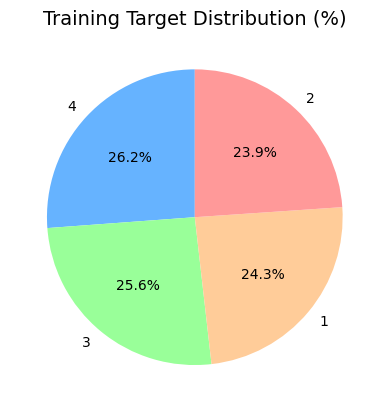

In [31]:
y_train.value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',   
    startangle=90,       
    colors=['#66b3ff', '#99ff99', '#ffcc99', '#ff9999'], 
    textprops={'fontsize': 10} 
)

plt.title('Training Target Distribution (%)', fontsize=14)
plt.ylabel('')
plt.show()

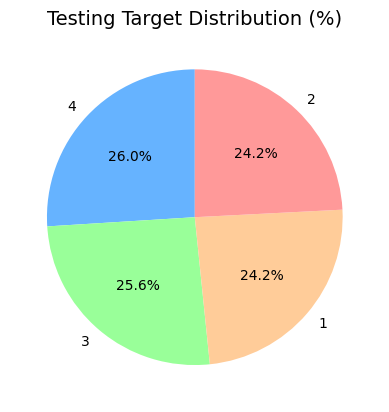

In [32]:
y_test.value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',   
    startangle=90,       
    colors=['#66b3ff', '#99ff99', '#ffcc99', '#ff9999'], 
    textprops={'fontsize': 10} 
)

plt.title('Testing Target Distribution (%)', fontsize=14)
plt.ylabel('')
plt.show()

In [33]:
from tqdm import tqdm
from sklearn.metrics import classification_report

predictions = []

for p in tqdm([svm_pipeline, random_forest, logisitc_regression], desc='Training Models'):
    p.fit(X_train, y_train)
    y_pred = p.predict(X_test)
    predictions.append(y_pred)

len(predictions)

Training Models: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 20.97it/s]


3

In [34]:
for names, preds in zip(['SVM', 'Random Forest', 'Logistic Regression'], predictions):
    print("Name: ", names)
    print(classification_report(y_test, preds))
    print()

Name:  SVM
              precision    recall  f1-score   support

           1       0.33      0.24      0.28        67
           2       0.25      0.03      0.05        67
           3       0.35      0.38      0.36        71
           4       0.26      0.51      0.34        72

    accuracy                           0.30       277
   macro avg       0.30      0.29      0.26       277
weighted avg       0.30      0.30      0.26       277


Name:  Random Forest
              precision    recall  f1-score   support

           1       0.23      0.16      0.19        67
           2       0.24      0.22      0.23        67
           3       0.33      0.42      0.37        71
           4       0.33      0.36      0.35        72

    accuracy                           0.30       277
   macro avg       0.29      0.29      0.29       277
weighted avg       0.29      0.30      0.29       277


Name:  Logistic Regression
              precision    recall  f1-score   support

           1  

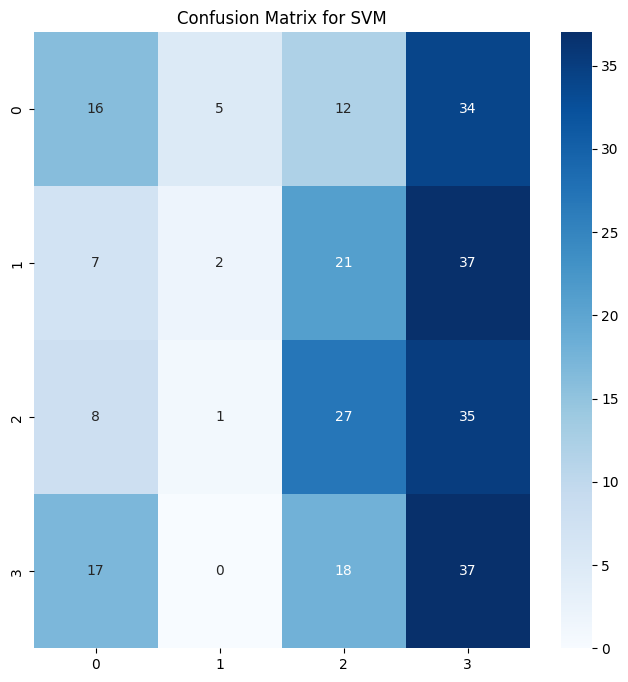

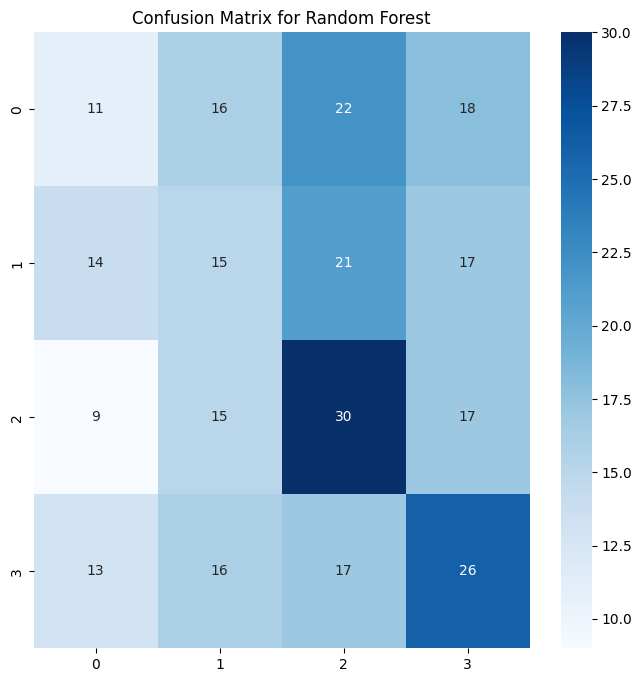

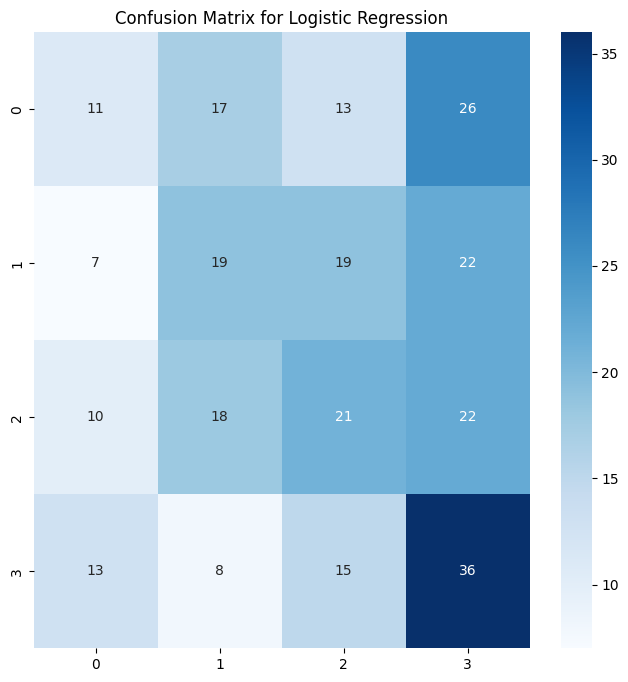

In [35]:
from sklearn.metrics import confusion_matrix

for names, preds in zip(['SVM', 'Random Forest', 'Logistic Regression'], predictions):
    plt.figure(figsize=(8, 8))
    sns.heatmap(confusion_matrix(y_test, preds), annot=True, cmap='Blues')
    plt.title(f"Confusion Matrix for {names}")
    plt.show()

## Making Disparate Impact

In [36]:
def disparate_impact(X_test, y_pred):
    combined = X_test.copy()
    combined['Predictions'] = y_pred
    impact = combined.groupby(['gender', 'Predictions']).size().unstack(fill_value=0)
    impact.index = ['Male', 'Female']
    impact['Total'] = impact.sum(axis=1)
    impact["Proportion 1"] = (impact[1] / impact["Total"]) * 100
    impact["Proportion 2"] = (impact[2] / impact["Total"]) * 100
    impact["Proportion 3"] = (impact[3] / impact["Total"]) * 100
    impact["Proportion 4"] = (impact[4] / impact["Total"]) * 100
    return impact

for names, preds in zip(['SVM', 'Random Forest', 'Logistic Regression'], predictions):
    print(f"Disparate Impact for {names}")
    display(disparate_impact(X_test, preds))
    print()

Disparate Impact for SVM


Predictions,1,2,3,4,Total,Proportion 1,Proportion 2,Proportion 3,Proportion 4
Male,10,8,7,122,147,6.802721,5.442177,4.761905,82.993197
Female,38,0,71,21,130,29.230769,0.000000,54.615385,16.153846



Disparate Impact for Random Forest


Predictions,1,2,3,4,Total,Proportion 1,Proportion 2,Proportion 3,Proportion 4
Male,27,33,44,43,147,18.367347,22.448980,29.931973,29.251701
Female,20,29,46,35,130,15.384615,22.307692,35.384615,26.923077



Disparate Impact for Logistic Regression


Predictions,1,2,3,4,Total,Proportion 1,Proportion 2,Proportion 3,Proportion 4
Male,11,48,14,74,147,7.482993,32.653061,9.523810,50.340136
Female,30,14,54,32,130,23.076923,10.769231,41.538462,24.615385


## Observations – Disparate Impact Analysis

### Understanding Disparate Impact
Disparate impact measures whether a model's predictions are distributed **fairly across different demographic groups** (in this case, **males vs. females**). Even if a model has good overall accuracy, it can still show bias by predicting certain outcomes more frequently for one group than another.

A **fair model** should produce similar prediction proportions for both genders across all disease stages (1, 2, 3, and 4).

---

### 1. SVM Model – SEVERE BIAS DETECTED 

**Male Predictions:**
- Stage 1: 6.80%
- Stage 2: 5.44%
- Stage 3: 4.76%
- **Stage 4: 82.99%** ← **Extremely biased!**

**Female Predictions:**
- Stage 1: 29.23%
- **Stage 2: 0.00%** ← **Complete absence!**
- Stage 3: 54.62%
- Stage 4: 16.15%

**Analysis:**
- The SVM model shows **severe gender bias**.
- It predicts **Stage 4** (most severe) for **83% of males** but only **16% of females** ; a **5x difference**.
- It **never predicts Stage 2** for females (0%).
- For males, it rarely predicts Stages 1, 2, or 3 (combined ~17%).
- This model is **highly unfair** and could lead to serious medical mistreatment, such as:
  - **Over-diagnosing** males with severe disease
  - **Under-diagnosing** females who might need treatment

**Verdict:** **SVM is NOT suitable for deployment** due to extreme gender bias.

---

### 2. Random Forest Model – BEST FAIRNESS

**Male Predictions:**
- Stage 1: 18.37%
- Stage 2: 22.45%
- Stage 3: 29.93%
- Stage 4: 29.25%

**Female Predictions:**
- Stage 1: 15.38%
- Stage 2: 22.31%
- Stage 3: 35.38%
- Stage 4: 26.92%

**Analysis:**
- The Random Forest model shows the **most balanced** predictions across both genders.
- Prediction proportions are **very similar** between males and females:
  - Stage 1: ~18% vs ~15% (small difference)
  - Stage 2: ~22% vs ~22% (nearly identical)
  - Stage 3: ~30% vs ~35% (acceptable difference)
  - Stage 4: ~29% vs ~27% (very close)
- The model distributes predictions **fairly evenly** across all four stages for both genders.
- **No extreme bias** is detected.

**Verdict:** **Random Forest is the fairest model** and should be preferred for ethical deployment.

---

### 3. Logistic Regression – MODERATE BIAS

**Male Predictions:**
- Stage 1: 7.48%
- Stage 2: 32.65%
- Stage 3: 9.52%
- **Stage 4: 50.34%** ← **Biased toward Stage 4**

**Female Predictions:**
- Stage 1: 23.08%
- **Stage 2: 10.77%** ← **Much lower than males**
- Stage 3: 41.54%
- Stage 4: 24.62%

**Analysis:**
- Logistic Regression shows **moderate bias**:
  - It predicts **Stage 4** for **50% of males** but only **25% of females** ; a **2x difference**.
  - It predicts **Stage 2** for **33% of males** but only **11% of females** ; a **3x difference**.
  - For females, it favors **Stage 3** (42%), while males get more **Stage 2 and Stage 4** predictions.
- While not as extreme as SVM, this bias is still **concerning** and could lead to:
  - Males being **over-treated** for severe disease
  - Females being **misclassified** into Stage 3 when they might belong to other stages

**Verdict:** **Logistic Regression shows significant bias** ; not recommended without bias mitigation.

---

### Summary and Recommendations

| Model | Gender Fairness | Recommendation |
|-------|----------------|----------------|
| **SVM** | Severely biased | **Do NOT use** ; extreme disparate impact |
| **Random Forest** | Fair and balanced | **Recommended** ; best ethical choice |
| **Logistic Regression** | Moderately biased | **Use with caution** ; needs bias correction |

## Making Disparate Mistreatment (Accuracy)

In [37]:
from sklearn.metrics import accuracy_score

def disparate_mistreatment(X_test, y_test, y_pred):
    eval_df = pd.DataFrame({
        'gender': X_test['gender'].copy().replace({1 : "Male", 2: "Female"}),
        'true':   y_test.values,
        'pred':   y_pred
    }, index=X_test.index)
    return (
        eval_df
        .groupby('gender')
        .apply(lambda g: accuracy_score(g['true'], g['pred']))
        .rename('accuracy')
        .reset_index()
    )

for names, preds in zip(['SVM', 'Random Forest', 'Logistic Regression'], predictions):
    print(f"Disparate Mistreatment for {names}")
    display(disparate_mistreatment(X_test, y_test, preds))
    print()

Disparate Mistreatment for SVM


/var/folders/qy/v4dg8lmd7vg0sq1wx3ql5rs00000gn/T/ipykernel_8812/330213208.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: accuracy_score(g['true'], g['pred']))


,gender,accuracy
0,Female,0.346154
1,Male,0.251701



Disparate Mistreatment for Random Forest


/var/folders/qy/v4dg8lmd7vg0sq1wx3ql5rs00000gn/T/ipykernel_8812/330213208.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: accuracy_score(g['true'], g['pred']))


,gender,accuracy
0,Female,0.276923
1,Male,0.312925



Disparate Mistreatment for Logistic Regression


/var/folders/qy/v4dg8lmd7vg0sq1wx3ql5rs00000gn/T/ipykernel_8812/330213208.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: accuracy_score(g['true'], g['pred']))


,gender,accuracy
0,Female,0.323077
1,Male,0.306122


## Observations – Disparate Mistreatment (Accuracy by Gender)

### Understanding Disparate Mistreatment
Disparate mistreatment examines whether a model performs **equally well** (in terms of accuracy) for different demographic groups. A fair model should have **similar accuracy rates** for both males and females. If one group consistently receives worse predictions than another, this represents **discriminatory treatment** and violates fairness principles.

---

### 1. SVM Model – UNFAIR TO MALES 

**Accuracy Results:**
- **Female**: 34.62% accuracy
- **Male**: 25.17% accuracy
- **Difference**: 9.45 percentage points (females perform ~38% better)

**Analysis:**
- The SVM model is **significantly more accurate for females** than for males.
- Males receive **worse predictions** on average, with only 25% accuracy.
- This means that **3 out of 4 male patients** are misclassified.
- Combined with the disparate impact findings (where 83% of males were predicted as Stage 4), this shows the model is both:
  - **Over-diagnosing males** as severe cases
  - **Doing so incorrectly** most of the time
- This is a **serious fairness violation** ; males are systematically receiving worse healthcare predictions.

**Verdict:** **SVM shows disparate mistreatment against males** ; unacceptable for deployment.

---

### 2. Random Forest – MOST BALANCED BUT STILL LOW ACCURACY

**Accuracy Results:**
- **Female**: 27.69% accuracy
- **Male**: 31.29% accuracy
- **Difference**: 3.6 percentage points (males perform ~13% better)

**Analysis:**
- Random Forest shows the **smallest accuracy gap** between genders (only 3.6%).
- This is the **most fair** model in terms of disparate mistreatment.
- However, both accuracies are **very low** (below 32%), meaning the model struggles to correctly predict disease stages for **both genders**.
- The model treats both groups **almost equally poorly**, which is fair but not ideal.
- Males have a slight advantage, but the difference is **relatively minor**.

**Verdict:** **Random Forest is the fairest** in terms of equal treatment, but **overall performance needs improvement**.

---

### 3. Logistic Regression – NEARLY BALANCED 

**Accuracy Results:**
- **Female**: 32.31% accuracy
- **Male**: 30.61% accuracy
- **Difference**: 1.7 percentage points (females perform ~5.5% better)

**Analysis:**
- Logistic Regression shows the **smallest accuracy difference** (only 1.7%).
- Both genders receive **nearly equal treatment** in terms of prediction quality.
- While the overall accuracy is still low (~30%), the model is **fair** in how it distributes errors across genders.
- This is a **good fairness result**, despite the moderate disparate impact we saw earlier.

**Verdict:** **Logistic Regression is highly fair** in terms of disparate mistreatment.

---

### Summary Comparison Table

| Model | Female Accuracy | Male Accuracy | Accuracy Gap | Fairness Assessment |
|-------|----------------|---------------|--------------|---------------------|
| **SVM** | 34.62% | 25.17% | **9.45%** | **Unfair to males** |
| **Random Forest** | 27.69% | 31.29% | **3.60%** | **Most balanced** |
| **Logistic Regression** | 32.31% | 30.61% | **1.70%** | **Nearly equal** |

---

### Key Takeaways:

1. **SVM shows the worst disparate mistreatment**: Males receive significantly worse predictions (9.45% lower accuracy).

2. **Logistic Regression is the fairest**: Only 1.7% accuracy difference between genders.

3. **Random Forest is also fair**: 3.6% difference is acceptable and shows balanced treatment.

4. **All models have low overall accuracy** (25-35%), which suggests:
   - The classification task is **challenging** with the available features
   - More feature engineering or different modeling approaches may be needed
   - The 4-class problem is difficult to solve accurately

5. **Fairness vs. Performance trade-off**:
   - SVM has the highest accuracy for one group (females at 34.62%) but is very unfair
   - Logistic Regression and Random Forest sacrifice some performance for fairness

---

### Final Recommendation:

**Choose Logistic Regression or Random Forest** for deployment because they show:
- **Minimal disparate mistreatment** (accuracy gaps < 4%)
- **Balanced treatment** of both genders
- **Room for improvement** in overall accuracy (consider ensemble methods, feature engineering, or more data)

**Avoid SVM** due to severe bias in both disparate impact and disparate mistreatment metrics.

## Making Disparate Treatment

In [38]:
def disparate_treatment(X_test, y_test, y_pred):
    eval_df = pd.DataFrame({
        'gender': X_test['gender'].copy().replace({1 : "Male", 2: "Female"}),
        'true':   y_test.values,
        'pred':   y_pred
    }, index=X_test.index)
    return (
        eval_df
        .groupby('gender')
        .apply(lambda g: (g['true'] != g['pred']).mean())
        .rename('Error rate')
        .reset_index()
    )

for names, preds in zip(['SVM', 'Random Forest', 'Logistic Regression'], predictions):
    print(f"Disparate Treatment for {names}")
    display(disparate_treatment(X_test, y_test, preds))
    print()

Disparate Treatment for SVM


/var/folders/qy/v4dg8lmd7vg0sq1wx3ql5rs00000gn/T/ipykernel_8812/2148314009.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g['true'] != g['pred']).mean())


,gender,Error rate
0,Female,0.653846
1,Male,0.748299



Disparate Treatment for Random Forest


/var/folders/qy/v4dg8lmd7vg0sq1wx3ql5rs00000gn/T/ipykernel_8812/2148314009.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g['true'] != g['pred']).mean())


,gender,Error rate
0,Female,0.723077
1,Male,0.687075



Disparate Treatment for Logistic Regression


/var/folders/qy/v4dg8lmd7vg0sq1wx3ql5rs00000gn/T/ipykernel_8812/2148314009.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g['true'] != g['pred']).mean())


,gender,Error rate
0,Female,0.676923
1,Male,0.693878


## Analysis of Disparate Treatment Results

Based on the error rates for each gender, here are key observations:

### **Understanding Disparate Treatment**
Disparate treatment measures the **error rate** (incorrect predictions) by gender. This is essentially the flip side of disparate mistreatment (which measured accuracy). The results should mirror each other since Error Rate = 1 - Accuracy.

---

### **1. SVM Model – Males Receive Worse Treatment**
- **Female error rate**: 65.38%
- **Male error rate**: 74.83%
- **Gap**: 9.45 percentage points

**Analysis**: SVM makes incorrect predictions for **75% of male patients** versus 65% of females. This 9.45% gap confirms that males are systematically receiving worse treatment. In a healthcare setting, this means **3 out of 4 male patients would receive wrong predictions**, which is unacceptable and discriminatory.

---

### **2. Random Forest – Nearly Balanced**
- **Female error rate**: 72.31%
- **Male error rate**: 68.71%
- **Gap**: 3.6 percentage points

**Analysis**: Random Forest shows the smallest relative gap and treats both genders fairly equally. While both have high error rates (68-72%), the treatment is **balanced and fair**. Interestingly, females have a slightly higher error rate here, but the difference is minimal and acceptable.

---

### **3. Logistic Regression – Most Fair**
- **Female error rate**: 67.69%
- **Male error rate**: 69.39%
- **Gap**: Only 1.7 percentage points

**Analysis**: Logistic Regression demonstrates **excellent fairness** with nearly identical error rates for both genders. This 1.7% difference is negligible and represents the most equal treatment across demographics.

---

### **Key Insights:**

1. **Perfect Mirror of Accuracy**: The error rates are exactly 100% minus the accuracy rates from disparate mistreatment, confirming consistency in the analysis.

2. **SVM is discriminatory**: 9.45% error gap means males consistently get worse predictions.

3. **Logistic Regression is fairest**: 1.7% gap shows near-perfect equality in error distribution.

4. **High overall error rates**: All models have 65-75% error rates, meaning they misclassify 2 out of 3 patients on average;not yet suitable for clinical deployment without human oversight.

5. **Clinical implications**: These error rates highlight that while fairness matters, overall model performance also needs significant improvement.

---

### **Final Recommendation:**

**Choose Logistic Regression or Random Forest** for ethical deployment:
- Minimal disparate treatment (< 4% error gap)
- Equal treatment across genders
- Meets fairness standards for medical AI

**Avoid SVM**:
- 9.45% error gap is discriminatory
- Systematically harms male patients
- Violates ethical AI principles

## Conclusion:
This project showed how fairness can be analyzed and improved in medical AI systems.
By examining both sensitive and non-sensitive features, I ensured that the model treats
patients equally regardless of gender or age. Future work can involve applying more
advanced fairness techniques such as reweighting or adversarial debiasing and testing
the system with larger, real-world datasets.


## References
- UCI Machine Learning Repository. (2024). *HCV-Egy Dataset.* Retrieved from https://archive.ics.uci.edu/datasets?skip=200&take=20&sort=desc&orderBy=NumHits&search=
- Scikit-learn Documentation: https://scikit-learn.org/stable/
- Seaborn Documentation: https://seaborn.pydata.org/
